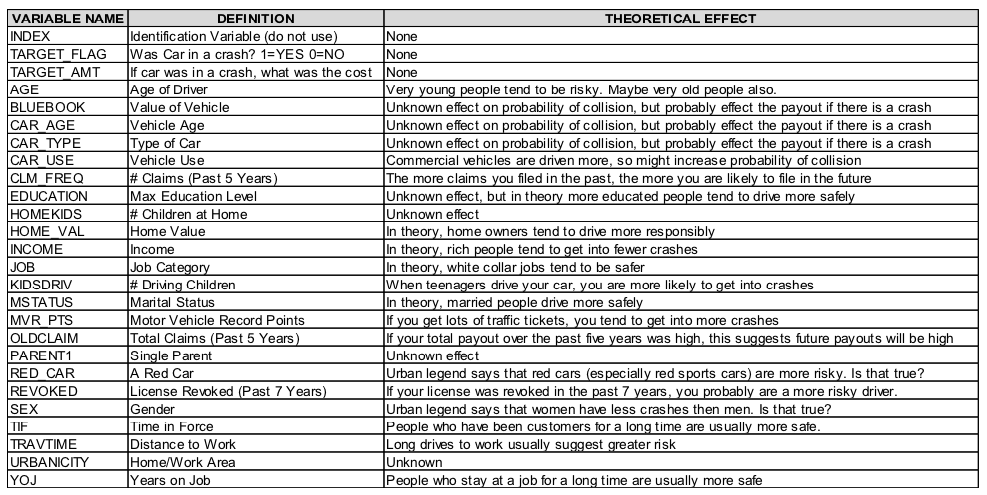

# Import Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px

# Load Data

In [2]:
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('car_insurance_claim.csv')
df.head()

,ID,KIDSDRIV,BIRTH,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,GENDER,EDUCATION,OCCUPATION,TRAVTIME,CAR_USE,BLUEBOOK,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CLM_AMT,CAR_AGE,CLAIM_FLAG,URBANICITY
0,63581743,0,16MAR39,60.0,0,11.0,"$67,349",No,$0,z_No,M,PhD,Professional,14,Private,"$14,230",11,Minivan,yes,"$4,461",2,No,3,$0,18.0,0,Highly Urban/ Urban
1,132761049,0,21JAN56,43.0,0,11.0,"$91,449",No,"$257,252",z_No,M,z_High School,z_Blue Collar,22,Commercial,"$14,940",1,Minivan,yes,$0,0,No,0,$0,1.0,0,Highly Urban/ Urban
2,921317019,0,18NOV51,48.0,0,11.0,"$52,881",No,$0,z_No,M,Bachelors,Manager,26,Private,"$21,970",1,Van,yes,$0,0,No,2,$0,10.0,0,Highly Urban/ Urban
3,727598473,0,05MAR64,35.0,1,10.0,"$16,039",No,"$124,191",Yes,z_F,z_High School,Clerical,5,Private,"$4,010",4,z_SUV,no,"$38,690",2,No,3,$0,10.0,0,Highly Urban/ Urban
4,450221861,0,05JUN48,51.0,0,14.0,NaN,No,"$306,251",Yes,M,<High School,z_Blue Collar,32,Private,"$15,440",7,Minivan,yes,$0,0,No,0,$0,6.0,0,Highly Urban/ Urban


# Data Overview

### Check Data Info

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10302 entries, 0 to 10301
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          10302 non-null  int64  
 1   KIDSDRIV    10302 non-null  int64  
 2   BIRTH       10302 non-null  object 
 3   AGE         10295 non-null  float64
 4   HOMEKIDS    10302 non-null  int64  
 5   YOJ         9754 non-null   float64
 6   INCOME      9732 non-null   object 
 7   PARENT1     10302 non-null  object 
 8   HOME_VAL    9727 non-null   object 
 9   MSTATUS     10302 non-null  object 
 10  GENDER      10302 non-null  object 
 11  EDUCATION   10302 non-null  object 
 12  OCCUPATION  9637 non-null   object 
 13  TRAVTIME    10302 non-null  int64  
 14  CAR_USE     10302 non-null  object 
 15  BLUEBOOK    10302 non-null  object 
 16  TIF         10302 non-null  int64  
 17  CAR_TYPE    10302 non-null  object 
 18  RED_CAR     10302 non-null  object 
 19  OLDCLAIM    10302 non-nul

### Check summary statistics

In [6]:
df.describe().round(2)

,ID,KIDSDRIV,AGE,HOMEKIDS,YOJ,TRAVTIME,TIF,CLM_FREQ,MVR_PTS,CAR_AGE,CLAIM_FLAG
count,1.030200e+04,10302.00,10295.00,10302.00,9754.00,10302.00,10302.00,10302.00,10302.00,9663.00,10302.00
mean,4.956631e+08,0.17,44.84,0.72,10.47,33.42,5.33,0.80,1.71,8.30,0.27
std,2.864675e+08,0.51,8.61,1.12,4.11,15.87,4.11,1.15,2.16,5.71,0.44
min,6.317500e+04,0.00,16.00,0.00,0.00,5.00,1.00,0.00,0.00,-3.00,0.00
25%,2.442869e+08,0.00,39.00,0.00,9.00,22.00,1.00,0.00,0.00,1.00,0.00
50%,4.970043e+08,0.00,45.00,0.00,11.00,33.00,4.00,0.00,1.00,8.00,0.00
75%,7.394551e+08,0.00,51.00,1.00,13.00,44.00,7.00,2.00,3.00,12.00,1.00
max,9.999264e+08,4.00,81.00,5.00,23.00,142.00,25.00,5.00,13.00,28.00,1.00


In [309]:
df.describe(include= 'object')

,BIRTH,INCOME,PARENT1,HOME_VAL,MSTATUS,GENDER,EDUCATION,OCCUPATION,CAR_USE,BLUEBOOK,CAR_TYPE,RED_CAR,OLDCLAIM,REVOKED,CLM_AMT,URBANICITY
count,10302,9732,10302,9727,10302,10302,10302,9637,10302,10302,10302,10302,10302,10302,10302,10302
unique,6560,8151,2,6334,2,2,5,8,2,2985,6,2,3545,2,2346,2
top,20OCT60,$0,No,$0,Yes,z_F,z_High School,z_Blue Collar,Private,"$1,500",z_SUV,no,$0,No,$0,Highly Urban/ Urban
freq,8,797,8959,2908,6188,5545,2952,2288,6513,207,2883,7326,6292,9041,7556,8230


### Check duplicates

In [310]:
df.duplicated().sum()

1

In [311]:
df.drop_duplicates(inplace= True, ignore_index= True)

In [312]:
df

,ID,KIDSDRIV,BIRTH,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,GENDER,EDUCATION,OCCUPATION,TRAVTIME,CAR_USE,BLUEBOOK,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CLM_AMT,CAR_AGE,CLAIM_FLAG,URBANICITY
0,63581743,0,16MAR39,60.0,0,11.0,"$67,349",No,$0,z_No,M,PhD,Professional,14,Private,"$14,230",11,Minivan,yes,"$4,461",2,No,3,$0,18.0,0,Highly Urban/ Urban
1,132761049,0,21JAN56,43.0,0,11.0,"$91,449",No,"$257,252",z_No,M,z_High School,z_Blue Collar,22,Commercial,"$14,940",1,Minivan,yes,$0,0,No,0,$0,1.0,0,Highly Urban/ Urban
2,921317019,0,18NOV51,48.0,0,11.0,"$52,881",No,$0,z_No,M,Bachelors,Manager,26,Private,"$21,970",1,Van,yes,$0,0,No,2,$0,10.0,0,Highly Urban/ Urban
3,727598473,0,05MAR64,35.0,1,10.0,"$16,039",No,"$124,191",Yes,z_F,z_High School,Clerical,5,Private,"$4,010",4,z_SUV,no,"$38,690",2,No,3,$0,10.0,0,Highly Urban/ Urban
4,450221861,0,05JUN48,51.0,0,14.0,NaN,No,"$306,251",Yes,M,<High School,z_Blue Collar,32,Private,"$15,440",7,Minivan,yes,$0,0,No,0,$0,6.0,0,Highly Urban/ Urban
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10296,67790126,1,13AUG54,45.0,2,9.0,"$164,669",No,"$386,273",Yes,M,PhD,Manager,21,Private,"$13,270",15,Minivan,no,$0,0,No,2,$0,17.0,0,Highly Urban/ Urban
10297,61970712,0,17JUN53,46.0,0,9.0,"$107,204",No,"$332,591",Yes,M,Masters,NaN,36,Commercial,"$24,490",6,Panel Truck,no,$0,0,No,0,$0,1.0,0,Highly Urban/ Urban
10298,849208064,0,18JUN51,48.0,0,15.0,"$39,837",No,"$170,611",Yes,z_F,<High School,z_Blue Collar,12,Private,"$13,820",7,z_SUV,no,$0,0,No,0,$0,1.0,0,Highly Urban/ Urban
10299,627828331,0,12DEC48,50.0,0,7.0,"$43,445",No,"$149,248",Yes,z_F,Bachelors,Home Maker,36,Private,"$22,550",6,Minivan,no,$0,0,No,0,$0,11.0,0,Highly Urban/ Urban


### Check missing values

In [313]:
df.isna().sum()

ID              0
KIDSDRIV        0
BIRTH           0
AGE             7
HOMEKIDS        0
YOJ           548
INCOME        570
PARENT1         0
HOME_VAL      575
MSTATUS         0
GENDER          0
EDUCATION       0
OCCUPATION    665
TRAVTIME        0
CAR_USE         0
BLUEBOOK        0
TIF             0
CAR_TYPE        0
RED_CAR         0
OLDCLAIM        0
CLM_FREQ        0
REVOKED         0
MVR_PTS         0
CLM_AMT         0
CAR_AGE       639
CLAIM_FLAG      0
URBANICITY      0
dtype: int64

In [314]:
round((df.isna().mean()) * 100, 3)

ID            0.000
KIDSDRIV      0.000
BIRTH         0.000
AGE           0.068
HOMEKIDS      0.000
YOJ           5.320
INCOME        5.533
PARENT1       0.000
HOME_VAL      5.582
MSTATUS       0.000
GENDER        0.000
EDUCATION     0.000
OCCUPATION    6.456
TRAVTIME      0.000
CAR_USE       0.000
BLUEBOOK      0.000
TIF           0.000
CAR_TYPE      0.000
RED_CAR       0.000
OLDCLAIM      0.000
CLM_FREQ      0.000
REVOKED       0.000
MVR_PTS       0.000
CLM_AMT       0.000
CAR_AGE       6.203
CLAIM_FLAG    0.000
URBANICITY    0.000
dtype: float64

In [315]:
round((df.isna().sum() / df.shape[0]) * 100, 2)

ID            0.00
KIDSDRIV      0.00
BIRTH         0.00
AGE           0.07
HOMEKIDS      0.00
YOJ           5.32
INCOME        5.53
PARENT1       0.00
HOME_VAL      5.58
MSTATUS       0.00
GENDER        0.00
EDUCATION     0.00
OCCUPATION    6.46
TRAVTIME      0.00
CAR_USE       0.00
BLUEBOOK      0.00
TIF           0.00
CAR_TYPE      0.00
RED_CAR       0.00
OLDCLAIM      0.00
CLM_FREQ      0.00
REVOKED       0.00
MVR_PTS       0.00
CLM_AMT       0.00
CAR_AGE       6.20
CLAIM_FLAG    0.00
URBANICITY    0.00
dtype: float64

# Data Cleaning

In [316]:
# Make columns lowercase
df.columns = df.columns.str.lower()
df.columns

Index(['id', 'kidsdriv', 'birth', 'age', 'homekids', 'yoj', 'income',
       'parent1', 'home_val', 'mstatus', 'gender', 'education', 'occupation',
       'travtime', 'car_use', 'bluebook', 'tif', 'car_type', 'red_car',
       'oldclaim', 'clm_freq', 'revoked', 'mvr_pts', 'clm_amt', 'car_age',
       'claim_flag', 'urbanicity'],
      dtype='object')

In [317]:
# Check count of dataframe if missing values were dropped from these collumns
df.dropna(subset= ['yoj', 'income', 'home_val', 'occupation', 'car_age'])

,id,kidsdriv,birth,age,homekids,yoj,income,parent1,home_val,mstatus,gender,education,occupation,travtime,car_use,bluebook,tif,car_type,red_car,oldclaim,clm_freq,revoked,mvr_pts,clm_amt,car_age,claim_flag,urbanicity
0,63581743,0,16MAR39,60.0,0,11.0,"$67,349",No,$0,z_No,M,PhD,Professional,14,Private,"$14,230",11,Minivan,yes,"$4,461",2,No,3,$0,18.0,0,Highly Urban/ Urban
1,132761049,0,21JAN56,43.0,0,11.0,"$91,449",No,"$257,252",z_No,M,z_High School,z_Blue Collar,22,Commercial,"$14,940",1,Minivan,yes,$0,0,No,0,$0,1.0,0,Highly Urban/ Urban
2,921317019,0,18NOV51,48.0,0,11.0,"$52,881",No,$0,z_No,M,Bachelors,Manager,26,Private,"$21,970",1,Van,yes,$0,0,No,2,$0,10.0,0,Highly Urban/ Urban
3,727598473,0,05MAR64,35.0,1,10.0,"$16,039",No,"$124,191",Yes,z_F,z_High School,Clerical,5,Private,"$4,010",4,z_SUV,no,"$38,690",2,No,3,$0,10.0,0,Highly Urban/ Urban
6,871024631,0,05MAY65,34.0,1,12.0,"$125,301",Yes,$0,z_No,z_F,Bachelors,z_Blue Collar,46,Commercial,"$17,430",1,Sports Car,no,$0,0,No,0,"$2,946",7.0,1,Highly Urban/ Urban
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10295,121441578,0,01JUL64,35.0,0,11.0,"$43,112",No,$0,z_No,M,z_High School,z_Blue Collar,51,Commercial,"$27,330",10,Panel Truck,yes,$0,0,No,0,$0,8.0,0,z_Highly Rural/ Rural
10296,67790126,1,13AUG54,45.0,2,9.0,"$164,669",No,"$386,273",Yes,M,PhD,Manager,21,Private,"$13,270",15,Minivan,no,$0,0,No,2,$0,17.0,0,Highly Urban/ Urban
10298,849208064,0,18JUN51,48.0,0,15.0,"$39,837",No,"$170,611",Yes,z_F,<High School,z_Blue Collar,12,Private,"$13,820",7,z_SUV,no,$0,0,No,0,$0,1.0,0,Highly Urban/ Urban
10299,627828331,0,12DEC48,50.0,0,7.0,"$43,445",No,"$149,248",Yes,z_F,Bachelors,Home Maker,36,Private,"$22,550",6,Minivan,no,$0,0,No,0,$0,11.0,0,Highly Urban/ Urban


In [318]:
# Check the remaining percentage of data after removing rows with missing values
(df.dropna(subset= ['yoj', 'income', 'home_val', 'occupation', 'car_age']).shape[0] / df.shape[0]) * 100

74.36171245510145

In [319]:
# df[(df.yoj.isna()) & (df.income.isna())]

In [320]:
px.histogram(df.yoj)

In [321]:
df.yoj.mean()

10.47370039987696

In [322]:
df.yoj.median()

11.0

In [323]:
df.occupation.value_counts()

occupation
z_Blue Collar    2288
Clerical         1590
Professional     1407
Manager          1257
Lawyer           1031
Student           899
Home Maker        843
Doctor            321
Name: count, dtype: int64

In [324]:
# Since the most frequent category percentage is not very high compared to other categories, it is not recommended to fill nan with the mode
round(df.occupation.value_counts(normalize= True) * 100, 2)

occupation
z_Blue Collar    23.74
Clerical         16.50
Professional     14.60
Manager          13.04
Lawyer           10.70
Student           9.33
Home Maker        8.75
Doctor            3.33
Name: proportion, dtype: float64

In [325]:
# we can fill using Unknown or leave it with missing values
df.occupation.fillna('Unknown').value_counts()

occupation
z_Blue Collar    2288
Clerical         1590
Professional     1407
Manager          1257
Lawyer           1031
Student           899
Home Maker        843
Unknown           665
Doctor            321
Name: count, dtype: int64

In [326]:
df.occupation = df.occupation.fillna('Unknown')

### Check Categorical Data in details

In [327]:
df.select_dtypes(include= 'object').columns

Index(['birth', 'income', 'parent1', 'home_val', 'mstatus', 'gender',
       'education', 'occupation', 'car_use', 'bluebook', 'car_type', 'red_car',
       'oldclaim', 'revoked', 'clm_amt', 'urbanicity'],
      dtype='object')

In [328]:
cat_cols = ['birth', 'parent1', 'mstatus', 'gender',
       'education', 'occupation', 'car_use', 'car_type', 'red_car'
       , 'revoked', 'urbanicity']
print(cat_cols)

['birth', 'parent1', 'mstatus', 'gender', 'education', 'occupation', 'car_use', 'car_type', 'red_car', 'revoked', 'urbanicity']


In [329]:
for col in cat_cols:
    print(col)
    print(df[col].nunique())
    print(df[col].unique(), '\n', '*' * 100)

birth
6560
['16MAR39' '21JAN56' '18NOV51' ... '13AUG54' '18JUN51' '27FEB47'] 
 ****************************************************************************************************
parent1
2
['No' 'Yes'] 
 ****************************************************************************************************
mstatus
2
['z_No' 'Yes'] 
 ****************************************************************************************************
gender
2
['M' 'z_F'] 
 ****************************************************************************************************
education
5
['PhD' 'z_High School' 'Bachelors' '<High School' 'Masters'] 
 ****************************************************************************************************
occupation
9
['Professional' 'z_Blue Collar' 'Manager' 'Clerical' 'Doctor' 'Lawyer'
 'Unknown' 'Home Maker' 'Student'] 
 ****************************************************************************************************
car_use
2
['Private' 'Commercial'] 
 *******

In [330]:
remove_z_cols = ['mstatus', 'gender', 'education', 'occupation', 'car_type', 'urbanicity']
remove_z_cols

['mstatus', 'gender', 'education', 'occupation', 'car_type', 'urbanicity']

In [331]:
def remove_z(x):
    if 'z_' in x:
        return x.replace('z_', '')
    else:
        return x
    
for col in remove_z_cols:

    df[col] = df[col].apply(remove_z)

df[['mstatus', 'gender', 'education', 'occupation', 'car_type', 'urbanicity']]

,mstatus,gender,education,occupation,car_type,urbanicity
0,No,M,PhD,Professional,Minivan,Highly Urban/ Urban
1,No,M,High School,Blue Collar,Minivan,Highly Urban/ Urban
2,No,M,Bachelors,Manager,Van,Highly Urban/ Urban
3,Yes,F,High School,Clerical,SUV,Highly Urban/ Urban
4,Yes,M,<High School,Blue Collar,Minivan,Highly Urban/ Urban
...,...,...,...,...,...,...
10296,Yes,M,PhD,Manager,Minivan,Highly Urban/ Urban
10297,Yes,M,Masters,Unknown,Panel Truck,Highly Urban/ Urban
10298,Yes,F,<High School,Blue Collar,SUV,Highly Urban/ Urban
10299,Yes,F,Bachelors,Home Maker,Minivan,Highly Urban/ Urban


### Check Numerical Data in details

In [332]:
df.income

0         $67,349
1         $91,449
2         $52,881
3         $16,039
4             NaN
           ...   
10296    $164,669
10297    $107,204
10298     $39,837
10299     $43,445
10300     $53,235
Name: income, Length: 10301, dtype: object

In [333]:
type(1.5) == float

True

In [334]:
num_cols = ['income', 'home_val', 'bluebook', 'oldclaim', 'clm_amt']
num_cols

['income', 'home_val', 'bluebook', 'oldclaim', 'clm_amt']

In [335]:
def clean_num(x):

    if type(x) == float:
        return x
    
    elif ('$' in x) or (',' in x ):
        return x.replace('$', '').replace(',', '')

    else:
        return x

for col in num_cols:

    df[col] = df[col].apply(clean_num).astype('float')

df[['income', 'home_val', 'bluebook', 'oldclaim', 'clm_amt']]

,income,home_val,bluebook,oldclaim,clm_amt
0,67349.0,0.0,14230.0,4461.0,0.0
1,91449.0,257252.0,14940.0,0.0,0.0
2,52881.0,0.0,21970.0,0.0,0.0
3,16039.0,124191.0,4010.0,38690.0,0.0
4,NaN,306251.0,15440.0,0.0,0.0
...,...,...,...,...,...
10296,164669.0,386273.0,13270.0,0.0,0.0
10297,107204.0,332591.0,24490.0,0.0,0.0
10298,39837.0,170611.0,13820.0,0.0,0.0
10299,43445.0,149248.0,22550.0,0.0,0.0


In [336]:
'ahmed'.replace('a', 'A').replace('d', 'D')

'AhmeD'

In [337]:
px.histogram(df.car_age)

In [338]:
df.car_age = df.car_age.abs()
df.car_age

0        18.0
1         1.0
2        10.0
3        10.0
4         6.0
         ... 
10296    17.0
10297     1.0
10298     1.0
10299    11.0
10300     9.0
Name: car_age, Length: 10301, dtype: float64

In [339]:
px.histogram(df.car_age)

In [340]:
for col in df.select_dtypes(include= ['int', 'float']).columns:
    px.histogram(df[col], title= col).show()

In [341]:
df

,id,kidsdriv,birth,age,homekids,yoj,income,parent1,home_val,mstatus,gender,education,occupation,travtime,car_use,bluebook,tif,car_type,red_car,oldclaim,clm_freq,revoked,mvr_pts,clm_amt,car_age,claim_flag,urbanicity
0,63581743,0,16MAR39,60.0,0,11.0,67349.0,No,0.0,No,M,PhD,Professional,14,Private,14230.0,11,Minivan,yes,4461.0,2,No,3,0.0,18.0,0,Highly Urban/ Urban
1,132761049,0,21JAN56,43.0,0,11.0,91449.0,No,257252.0,No,M,High School,Blue Collar,22,Commercial,14940.0,1,Minivan,yes,0.0,0,No,0,0.0,1.0,0,Highly Urban/ Urban
2,921317019,0,18NOV51,48.0,0,11.0,52881.0,No,0.0,No,M,Bachelors,Manager,26,Private,21970.0,1,Van,yes,0.0,0,No,2,0.0,10.0,0,Highly Urban/ Urban
3,727598473,0,05MAR64,35.0,1,10.0,16039.0,No,124191.0,Yes,F,High School,Clerical,5,Private,4010.0,4,SUV,no,38690.0,2,No,3,0.0,10.0,0,Highly Urban/ Urban
4,450221861,0,05JUN48,51.0,0,14.0,NaN,No,306251.0,Yes,M,<High School,Blue Collar,32,Private,15440.0,7,Minivan,yes,0.0,0,No,0,0.0,6.0,0,Highly Urban/ Urban
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10296,67790126,1,13AUG54,45.0,2,9.0,164669.0,No,386273.0,Yes,M,PhD,Manager,21,Private,13270.0,15,Minivan,no,0.0,0,No,2,0.0,17.0,0,Highly Urban/ Urban
10297,61970712,0,17JUN53,46.0,0,9.0,107204.0,No,332591.0,Yes,M,Masters,Unknown,36,Commercial,24490.0,6,Panel Truck,no,0.0,0,No,0,0.0,1.0,0,Highly Urban/ Urban
10298,849208064,0,18JUN51,48.0,0,15.0,39837.0,No,170611.0,Yes,F,<High School,Blue Collar,12,Private,13820.0,7,SUV,no,0.0,0,No,0,0.0,1.0,0,Highly Urban/ Urban
10299,627828331,0,12DEC48,50.0,0,7.0,43445.0,No,149248.0,Yes,F,Bachelors,Home Maker,36,Private,22550.0,6,Minivan,no,0.0,0,No,0,0.0,11.0,0,Highly Urban/ Urban


# Data Analysis

### Which Occupation has the highest number of claims ?

In [342]:
occu_freq = df.groupby('occupation')['clm_freq'].sum().sort_values(ascending= False).reset_index()
occu_freq

,occupation,clm_freq
0,Blue Collar,1933
1,Clerical,1246
2,Professional,1135
3,Manager,915
4,Student,806
5,Lawyer,701
6,Unknown,670
7,Home Maker,613
8,Doctor,230


In [343]:
px.bar(occu_freq, x= 'occupation', y= 'clm_freq', title= 'Total number of claims per Profession',
       labels= {'clm_freq' : 'Total Number of claims'})

### What is total claim value for per car type ?

In [344]:
car_clm = df.groupby('car_type')['oldclaim'].sum().sort_values(ascending= False).reset_index()
car_clm

,car_type,oldclaim
0,SUV,11704247.0
1,Minivan,9213471.0
2,Pickup,7141718.0
3,Sports Car,6084652.0
4,Van,4093499.0
5,Panel Truck,3320453.0


In [345]:
px.bar(car_clm, x= 'car_type', y= 'oldclaim', title= 'Total claims Amount per Car Type',
       labels= {'oldclaim' : 'Total old claims amount'})

In [346]:
df.select_dtypes(include= ['int', 'float'])

,id,kidsdriv,age,homekids,yoj,income,home_val,travtime,bluebook,tif,oldclaim,clm_freq,mvr_pts,clm_amt,car_age,claim_flag
0,63581743,0,60.0,0,11.0,67349.0,0.0,14,14230.0,11,4461.0,2,3,0.0,18.0,0
1,132761049,0,43.0,0,11.0,91449.0,257252.0,22,14940.0,1,0.0,0,0,0.0,1.0,0
2,921317019,0,48.0,0,11.0,52881.0,0.0,26,21970.0,1,0.0,0,2,0.0,10.0,0
3,727598473,0,35.0,1,10.0,16039.0,124191.0,5,4010.0,4,38690.0,2,3,0.0,10.0,0
4,450221861,0,51.0,0,14.0,NaN,306251.0,32,15440.0,7,0.0,0,0,0.0,6.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10296,67790126,1,45.0,2,9.0,164669.0,386273.0,21,13270.0,15,0.0,0,2,0.0,17.0,0
10297,61970712,0,46.0,0,9.0,107204.0,332591.0,36,24490.0,6,0.0,0,0,0.0,1.0,0
10298,849208064,0,48.0,0,15.0,39837.0,170611.0,12,13820.0,7,0.0,0,0,0.0,1.0,0
10299,627828331,0,50.0,0,7.0,43445.0,149248.0,36,22550.0,6,0.0,0,0,0.0,11.0,0


### Does kids driving affect number of claims ?

In [347]:
px.scatter(df, x= 'kidsdriv', y= 'clm_freq')

In [348]:
px.box(df, x= 'kidsdriv', y= 'clm_freq')

In [349]:
df[['kidsdriv', 'clm_freq']].corr()

,kidsdriv,clm_freq
kidsdriv,1.00000,0.03893
clm_freq,0.03893,1.00000


### Is there any positive or negative correlation between numerical columns ?

In [350]:
df.select_dtypes(include= ['int', 'float']).corr()

,id,kidsdriv,age,homekids,yoj,income,home_val,travtime,bluebook,tif,oldclaim,clm_freq,mvr_pts,clm_amt,car_age,claim_flag
id,1.000000,0.003484,-0.010474,0.009097,-0.011002,-0.021532,-0.014317,-0.002430,-0.000221,-0.010274,0.002581,-0.001487,0.008334,-0.012781,-0.004804,-0.005983
kidsdriv,0.003484,1.000000,-0.078451,0.463644,0.043002,-0.043196,-0.015424,0.012198,-0.028512,-0.005865,0.023872,0.038930,0.048400,0.068273,-0.059724,0.108404
age,-0.010474,-0.078451,1.000000,-0.447848,0.140946,0.186257,0.209658,-0.001587,0.166286,-0.001960,-0.033409,-0.037688,-0.075788,-0.049056,0.178578,-0.107013
homekids,0.009097,0.463644,-0.447848,1.000000,0.077768,-0.160193,-0.107442,-0.000739,-0.108579,0.007444,0.029728,0.038619,0.064248,0.068628,-0.159205,0.123015
yoj,-0.011002,0.043002,0.140946,0.077768,1.000000,0.293856,0.272151,-0.017128,0.148101,0.024016,-0.005036,-0.023476,-0.041526,-0.026771,0.064865,-0.066216
income,-0.021532,-0.043196,0.186257,-0.160193,0.293856,1.000000,0.578922,-0.051835,0.429113,0.002433,-0.039316,-0.049175,-0.063445,-0.057665,0.417481,-0.142552
home_val,-0.014317,-0.015424,0.209658,-0.107442,0.272151,0.578922,1.000000,-0.035120,0.261977,0.006844,-0.059772,-0.093809,-0.092409,-0.091967,0.223410,-0.185355
travtime,-0.002430,0.012198,-0.001587,-0.000739,-0.017128,-0.051835,-0.035120,1.000000,-0.022539,-0.013357,-0.013819,0.008255,0.009673,0.031262,-0.033249,0.053268
bluebook,-0.000221,-0.028512,0.166286,-0.108579,0.148101,0.429113,0.261977,-0.022539,1.000000,0.000693,-0.030731,-0.042138,-0.044828,-0.002446,0.194395,-0.103295
tif,-0.010274,-0.005865,-0.001960,0.007444,0.024016,0.002433,0.006844,-0.013357,0.000693,1.000000,-0.015569,-0.017450,-0.031247,-0.046553,0.007724,-0.081293


In [351]:
px.imshow(df.select_dtypes(include= ['int', 'float']).corr())

In [352]:
df

,id,kidsdriv,birth,age,homekids,yoj,income,parent1,home_val,mstatus,gender,education,occupation,travtime,car_use,bluebook,tif,car_type,red_car,oldclaim,clm_freq,revoked,mvr_pts,clm_amt,car_age,claim_flag,urbanicity
0,63581743,0,16MAR39,60.0,0,11.0,67349.0,No,0.0,No,M,PhD,Professional,14,Private,14230.0,11,Minivan,yes,4461.0,2,No,3,0.0,18.0,0,Highly Urban/ Urban
1,132761049,0,21JAN56,43.0,0,11.0,91449.0,No,257252.0,No,M,High School,Blue Collar,22,Commercial,14940.0,1,Minivan,yes,0.0,0,No,0,0.0,1.0,0,Highly Urban/ Urban
2,921317019,0,18NOV51,48.0,0,11.0,52881.0,No,0.0,No,M,Bachelors,Manager,26,Private,21970.0,1,Van,yes,0.0,0,No,2,0.0,10.0,0,Highly Urban/ Urban
3,727598473,0,05MAR64,35.0,1,10.0,16039.0,No,124191.0,Yes,F,High School,Clerical,5,Private,4010.0,4,SUV,no,38690.0,2,No,3,0.0,10.0,0,Highly Urban/ Urban
4,450221861,0,05JUN48,51.0,0,14.0,NaN,No,306251.0,Yes,M,<High School,Blue Collar,32,Private,15440.0,7,Minivan,yes,0.0,0,No,0,0.0,6.0,0,Highly Urban/ Urban
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10296,67790126,1,13AUG54,45.0,2,9.0,164669.0,No,386273.0,Yes,M,PhD,Manager,21,Private,13270.0,15,Minivan,no,0.0,0,No,2,0.0,17.0,0,Highly Urban/ Urban
10297,61970712,0,17JUN53,46.0,0,9.0,107204.0,No,332591.0,Yes,M,Masters,Unknown,36,Commercial,24490.0,6,Panel Truck,no,0.0,0,No,0,0.0,1.0,0,Highly Urban/ Urban
10298,849208064,0,18JUN51,48.0,0,15.0,39837.0,No,170611.0,Yes,F,<High School,Blue Collar,12,Private,13820.0,7,SUV,no,0.0,0,No,0,0.0,1.0,0,Highly Urban/ Urban
10299,627828331,0,12DEC48,50.0,0,7.0,43445.0,No,149248.0,Yes,F,Bachelors,Home Maker,36,Private,22550.0,6,Minivan,no,0.0,0,No,0,0.0,11.0,0,Highly Urban/ Urban


### Drop unnecessary columns

In [353]:
df.drop(['id', 'birth'], axis= 1, inplace= True)
df

,kidsdriv,age,homekids,yoj,income,parent1,home_val,mstatus,gender,education,occupation,travtime,car_use,bluebook,tif,car_type,red_car,oldclaim,clm_freq,revoked,mvr_pts,clm_amt,car_age,claim_flag,urbanicity
0,0,60.0,0,11.0,67349.0,No,0.0,No,M,PhD,Professional,14,Private,14230.0,11,Minivan,yes,4461.0,2,No,3,0.0,18.0,0,Highly Urban/ Urban
1,0,43.0,0,11.0,91449.0,No,257252.0,No,M,High School,Blue Collar,22,Commercial,14940.0,1,Minivan,yes,0.0,0,No,0,0.0,1.0,0,Highly Urban/ Urban
2,0,48.0,0,11.0,52881.0,No,0.0,No,M,Bachelors,Manager,26,Private,21970.0,1,Van,yes,0.0,0,No,2,0.0,10.0,0,Highly Urban/ Urban
3,0,35.0,1,10.0,16039.0,No,124191.0,Yes,F,High School,Clerical,5,Private,4010.0,4,SUV,no,38690.0,2,No,3,0.0,10.0,0,Highly Urban/ Urban
4,0,51.0,0,14.0,NaN,No,306251.0,Yes,M,<High School,Blue Collar,32,Private,15440.0,7,Minivan,yes,0.0,0,No,0,0.0,6.0,0,Highly Urban/ Urban
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10296,1,45.0,2,9.0,164669.0,No,386273.0,Yes,M,PhD,Manager,21,Private,13270.0,15,Minivan,no,0.0,0,No,2,0.0,17.0,0,Highly Urban/ Urban
10297,0,46.0,0,9.0,107204.0,No,332591.0,Yes,M,Masters,Unknown,36,Commercial,24490.0,6,Panel Truck,no,0.0,0,No,0,0.0,1.0,0,Highly Urban/ Urban
10298,0,48.0,0,15.0,39837.0,No,170611.0,Yes,F,<High School,Blue Collar,12,Private,13820.0,7,SUV,no,0.0,0,No,0,0.0,1.0,0,Highly Urban/ Urban
10299,0,50.0,0,7.0,43445.0,No,149248.0,Yes,F,Bachelors,Home Maker,36,Private,22550.0,6,Minivan,no,0.0,0,No,0,0.0,11.0,0,Highly Urban/ Urban


In [354]:
# Always check duplicates after removing columns from your data
df.duplicated().sum()

0

### Feature Engineering

In [355]:
df.tif.value_counts()

tif
1     3171
6     1707
4     1616
10     951
7      781
3      531
13     355
11     300
9      299
17     126
14      92
8       83
5       70
12      55
16      50
15      40
18      26
21      13
20      12
19      11
2        6
22       3
25       3
Name: count, dtype: int64

In [356]:
# Create a new column named loyal_cust based on years with the company
def loyal_cust(x):

    if x < 8:
        return 'New Customer'
    
    elif x < 15:
        return 'Loyal Customer'
    
    else:
        return 'Very Loyal Customer'
    
df.tif.apply(loyal_cust).value_counts()

tif
New Customer           7882
Loyal Customer         2135
Very Loyal Customer     284
Name: count, dtype: int64

In [357]:
df['customer_loyalty'] = df.tif.apply(loyal_cust)
df['customer_loyalty'] 

0             Loyal Customer
1               New Customer
2               New Customer
3               New Customer
4               New Customer
                ...         
10296    Very Loyal Customer
10297           New Customer
10298           New Customer
10299           New Customer
10300           New Customer
Name: customer_loyalty, Length: 10301, dtype: object

### Save cleaned dataframe for later use in streamlit python file

In [358]:
df.to_csv('cleaned_df.csv')

# Data Preprocessing

In [359]:
df.head()

,kidsdriv,age,homekids,yoj,income,parent1,home_val,mstatus,gender,education,occupation,travtime,car_use,bluebook,tif,car_type,red_car,oldclaim,clm_freq,revoked,mvr_pts,clm_amt,car_age,claim_flag,urbanicity,customer_loyalty
0,0,60.0,0,11.0,67349.0,No,0.0,No,M,PhD,Professional,14,Private,14230.0,11,Minivan,yes,4461.0,2,No,3,0.0,18.0,0,Highly Urban/ Urban,Loyal Customer
1,0,43.0,0,11.0,91449.0,No,257252.0,No,M,High School,Blue Collar,22,Commercial,14940.0,1,Minivan,yes,0.0,0,No,0,0.0,1.0,0,Highly Urban/ Urban,New Customer
2,0,48.0,0,11.0,52881.0,No,0.0,No,M,Bachelors,Manager,26,Private,21970.0,1,Van,yes,0.0,0,No,2,0.0,10.0,0,Highly Urban/ Urban,New Customer
3,0,35.0,1,10.0,16039.0,No,124191.0,Yes,F,High School,Clerical,5,Private,4010.0,4,SUV,no,38690.0,2,No,3,0.0,10.0,0,Highly Urban/ Urban,New Customer
4,0,51.0,0,14.0,NaN,No,306251.0,Yes,M,<High School,Blue Collar,32,Private,15440.0,7,Minivan,yes,0.0,0,No,0,0.0,6.0,0,Highly Urban/ Urban,New Customer


### Handling Missing Values

In [360]:
df.isna().sum()

kidsdriv              0
age                   7
homekids              0
yoj                 548
income              570
parent1               0
home_val            575
mstatus               0
gender                0
education             0
occupation            0
travtime              0
car_use               0
bluebook              0
tif                   0
car_type              0
red_car               0
oldclaim              0
clm_freq              0
revoked               0
mvr_pts               0
clm_amt               0
car_age             639
claim_flag            0
urbanicity            0
customer_loyalty      0
dtype: int64

In [361]:
round(df.isna().mean() * 100, 2)

kidsdriv            0.00
age                 0.07
homekids            0.00
yoj                 5.32
income              5.53
parent1             0.00
home_val            5.58
mstatus             0.00
gender              0.00
education           0.00
occupation          0.00
travtime            0.00
car_use             0.00
bluebook            0.00
tif                 0.00
car_type            0.00
red_car             0.00
oldclaim            0.00
clm_freq            0.00
revoked             0.00
mvr_pts             0.00
clm_amt             0.00
car_age             6.20
claim_flag          0.00
urbanicity          0.00
customer_loyalty    0.00
dtype: float64

In [362]:
df.dropna(subset= 'age', ignore_index= True, inplace= True)

In [363]:
df.dropna()

,kidsdriv,age,homekids,yoj,income,parent1,home_val,mstatus,gender,education,occupation,travtime,car_use,bluebook,tif,car_type,red_car,oldclaim,clm_freq,revoked,mvr_pts,clm_amt,car_age,claim_flag,urbanicity,customer_loyalty
0,0,60.0,0,11.0,67349.0,No,0.0,No,M,PhD,Professional,14,Private,14230.0,11,Minivan,yes,4461.0,2,No,3,0.0,18.0,0,Highly Urban/ Urban,Loyal Customer
1,0,43.0,0,11.0,91449.0,No,257252.0,No,M,High School,Blue Collar,22,Commercial,14940.0,1,Minivan,yes,0.0,0,No,0,0.0,1.0,0,Highly Urban/ Urban,New Customer
2,0,48.0,0,11.0,52881.0,No,0.0,No,M,Bachelors,Manager,26,Private,21970.0,1,Van,yes,0.0,0,No,2,0.0,10.0,0,Highly Urban/ Urban,New Customer
3,0,35.0,1,10.0,16039.0,No,124191.0,Yes,F,High School,Clerical,5,Private,4010.0,4,SUV,no,38690.0,2,No,3,0.0,10.0,0,Highly Urban/ Urban,New Customer
6,0,34.0,1,12.0,125301.0,Yes,0.0,No,F,Bachelors,Blue Collar,46,Commercial,17430.0,1,Sports Car,no,0.0,0,No,0,2946.0,7.0,1,Highly Urban/ Urban,New Customer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10289,1,45.0,2,9.0,164669.0,No,386273.0,Yes,M,PhD,Manager,21,Private,13270.0,15,Minivan,no,0.0,0,No,2,0.0,17.0,0,Highly Urban/ Urban,Very Loyal Customer
10290,0,46.0,0,9.0,107204.0,No,332591.0,Yes,M,Masters,Unknown,36,Commercial,24490.0,6,Panel Truck,no,0.0,0,No,0,0.0,1.0,0,Highly Urban/ Urban,New Customer
10291,0,48.0,0,15.0,39837.0,No,170611.0,Yes,F,<High School,Blue Collar,12,Private,13820.0,7,SUV,no,0.0,0,No,0,0.0,1.0,0,Highly Urban/ Urban,New Customer
10292,0,50.0,0,7.0,43445.0,No,149248.0,Yes,F,Bachelors,Home Maker,36,Private,22550.0,6,Minivan,no,0.0,0,No,0,0.0,11.0,0,Highly Urban/ Urban,New Customer


In [364]:
round(df.dropna().shape[0] / df.shape[0] * 100, 2)

79.29

In [365]:
px.histogram(df, x= 'yoj')

In [366]:
df.yoj.mean()

10.478247486148163

In [367]:
df.yoj.median()

11.0

In [368]:
from sklearn.impute import SimpleImputer, KNNImputer

# imputer = SimpleImputer(strategy= 'median')

# df[['yoj', 'car_age']] = imputer.fit_transform(df[['yoj', 'car_age']])
# df[['yoj', 'car_age']]

In [369]:
round(df.isna().mean() * 100, 2)

kidsdriv            0.00
age                 0.00
homekids            0.00
yoj                 5.32
income              5.53
parent1             0.00
home_val            5.57
mstatus             0.00
gender              0.00
education           0.00
occupation          0.00
travtime            0.00
car_use             0.00
bluebook            0.00
tif                 0.00
car_type            0.00
red_car             0.00
oldclaim            0.00
clm_freq            0.00
revoked             0.00
mvr_pts             0.00
clm_amt             0.00
car_age             6.21
claim_flag          0.00
urbanicity          0.00
customer_loyalty    0.00
dtype: float64

In [370]:
px.histogram(df, x= 'income')

In [371]:
# knn = KNNImputer()

# df[['income', 'home_val']] = knn.fit_transform(df[['income', 'home_val']])
# df[['income', 'home_val']]

In [372]:
px.histogram(df, x= 'income')

### Handling Categorical Data

In [373]:
df.select_dtypes(include= 'object')

,parent1,mstatus,gender,education,occupation,car_use,car_type,red_car,revoked,urbanicity,customer_loyalty
0,No,No,M,PhD,Professional,Private,Minivan,yes,No,Highly Urban/ Urban,Loyal Customer
1,No,No,M,High School,Blue Collar,Commercial,Minivan,yes,No,Highly Urban/ Urban,New Customer
2,No,No,M,Bachelors,Manager,Private,Van,yes,No,Highly Urban/ Urban,New Customer
3,No,Yes,F,High School,Clerical,Private,SUV,no,No,Highly Urban/ Urban,New Customer
4,No,Yes,M,<High School,Blue Collar,Private,Minivan,yes,No,Highly Urban/ Urban,New Customer
...,...,...,...,...,...,...,...,...,...,...,...
10289,No,Yes,M,PhD,Manager,Private,Minivan,no,No,Highly Urban/ Urban,Very Loyal Customer
10290,No,Yes,M,Masters,Unknown,Commercial,Panel Truck,no,No,Highly Urban/ Urban,New Customer
10291,No,Yes,F,<High School,Blue Collar,Private,SUV,no,No,Highly Urban/ Urban,New Customer
10292,No,Yes,F,Bachelors,Home Maker,Private,Minivan,no,No,Highly Urban/ Urban,New Customer


In [374]:
df.education.value_counts().index

Index(['High School', 'Bachelors', 'Masters', '<High School', 'PhD'], dtype='object', name='education')

In [375]:
from sklearn.preprocessing import OrdinalEncoder

ord = OrdinalEncoder(categories= [['<High School', 'High School', 'Bachelors', 'Masters', 'PhD']])

df['education'] = ord.fit_transform(df[['education']])
df['education']

0        4.0
1        1.0
2        2.0
3        1.0
4        0.0
        ... 
10289    4.0
10290    3.0
10291    0.0
10292    2.0
10293    1.0
Name: education, Length: 10294, dtype: float64

In [376]:
df.education

0        4.0
1        1.0
2        2.0
3        1.0
4        0.0
        ... 
10289    4.0
10290    3.0
10291    0.0
10292    2.0
10293    1.0
Name: education, Length: 10294, dtype: float64

In [377]:
for col in df.select_dtypes(include= 'object'):
    print(col)
    print(df[col].nunique())

parent1
2
mstatus
2
gender
2
occupation
9
car_use
2
car_type
6
red_car
2
revoked
2
urbanicity
2
customer_loyalty
3


In [378]:
ohe_cols = df.select_dtypes(include= 'object').drop('occupation', axis= 1).columns
ohe_cols

Index(['parent1', 'mstatus', 'gender', 'car_use', 'car_type', 'red_car',
       'revoked', 'urbanicity', 'customer_loyalty'],
      dtype='object')

In [379]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop= 'first', sparse_output= False)

ohe_arr = ohe.fit_transform(df[ohe_cols])
ohe_arr

array([[0., 0., 1., ..., 1., 0., 0.],
       [0., 0., 1., ..., 1., 1., 0.],
       [0., 0., 1., ..., 1., 1., 0.],
       ...,
       [0., 1., 0., ..., 1., 1., 0.],
       [0., 1., 0., ..., 1., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.]])

In [380]:
ohe_df = pd.DataFrame(ohe_arr, columns= ohe.get_feature_names_out())

In [381]:
df = pd.concat([df, ohe_df], axis= 1).drop(ohe_cols, axis= 1)
df.head()

,kidsdriv,age,homekids,yoj,income,home_val,education,occupation,travtime,bluebook,tif,oldclaim,clm_freq,mvr_pts,clm_amt,car_age,claim_flag,parent1_Yes,mstatus_Yes,gender_M,car_use_Private,car_type_Panel Truck,car_type_Pickup,car_type_SUV,car_type_Sports Car,car_type_Van,red_car_yes,revoked_Yes,urbanicity_Highly Urban/ Urban,customer_loyalty_New Customer,customer_loyalty_Very Loyal Customer
0,0,60.0,0,11.0,67349.0,0.0,4.0,Professional,14,14230.0,11,4461.0,2,3,0.0,18.0,0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0,43.0,0,11.0,91449.0,257252.0,1.0,Blue Collar,22,14940.0,1,0.0,0,0,0.0,1.0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
2,0,48.0,0,11.0,52881.0,0.0,2.0,Manager,26,21970.0,1,0.0,0,2,0.0,10.0,0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0
3,0,35.0,1,10.0,16039.0,124191.0,1.0,Clerical,5,4010.0,4,38690.0,2,3,0.0,10.0,0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,0,51.0,0,14.0,NaN,306251.0,0.0,Blue Collar,32,15440.0,7,0.0,0,0,0.0,6.0,0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


In [382]:
df.occupation.head(50)

0     Professional
1      Blue Collar
2          Manager
3         Clerical
4      Blue Collar
5           Doctor
6      Blue Collar
7      Blue Collar
8          Manager
9      Blue Collar
10     Blue Collar
11        Clerical
12    Professional
13          Lawyer
14    Professional
15         Manager
16         Unknown
17        Clerical
18      Home Maker
19        Clerical
20         Manager
21          Lawyer
22          Lawyer
23        Clerical
24     Blue Collar
25     Blue Collar
26          Lawyer
27     Blue Collar
28      Home Maker
29    Professional
30     Blue Collar
31    Professional
32        Clerical
33         Manager
34        Clerical
35      Home Maker
36     Blue Collar
37        Clerical
38     Blue Collar
39    Professional
40         Unknown
41     Blue Collar
42      Home Maker
43          Doctor
44        Clerical
45         Unknown
46          Doctor
47          Doctor
48         Student
49         Student
Name: occupation, dtype: object

In [383]:
from category_encoders import BinaryEncoder

be = BinaryEncoder()

be_df = be.fit_transform(df[['occupation']])
be_df

,occupation_0,occupation_1,occupation_2,occupation_3
0,0,0,0,1
1,0,0,1,0
2,0,0,1,1
3,0,1,0,0
4,0,0,1,0
...,...,...,...,...
10289,0,0,1,1
10290,0,1,1,1
10291,0,0,1,0
10292,1,0,0,0


In [384]:
df = pd.concat([df, be_df], axis= 1).drop('occupation', axis = 1)
df.head()

,kidsdriv,age,homekids,yoj,income,home_val,education,travtime,bluebook,tif,oldclaim,clm_freq,mvr_pts,clm_amt,car_age,claim_flag,parent1_Yes,mstatus_Yes,gender_M,car_use_Private,car_type_Panel Truck,car_type_Pickup,car_type_SUV,car_type_Sports Car,car_type_Van,red_car_yes,revoked_Yes,urbanicity_Highly Urban/ Urban,customer_loyalty_New Customer,customer_loyalty_Very Loyal Customer,occupation_0,occupation_1,occupation_2,occupation_3
0,0,60.0,0,11.0,67349.0,0.0,4.0,14,14230.0,11,4461.0,2,3,0.0,18.0,0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0,0,0,1
1,0,43.0,0,11.0,91449.0,257252.0,1.0,22,14940.0,1,0.0,0,0,0.0,1.0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0,0,1,0
2,0,48.0,0,11.0,52881.0,0.0,2.0,26,21970.0,1,0.0,0,2,0.0,10.0,0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0,0,1,1
3,0,35.0,1,10.0,16039.0,124191.0,1.0,5,4010.0,4,38690.0,2,3,0.0,10.0,0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0,1,0,0
4,0,51.0,0,14.0,NaN,306251.0,0.0,32,15440.0,7,0.0,0,0,0.0,6.0,0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0,0,1,0


### Split Data into Input Features and Target Column

In [389]:
x = df.drop('claim_flag', axis= 1)
y = df['claim_flag']

### Split data into Train & Test

In [390]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2,
                                                     random_state= 42, stratify= y)

In [391]:
x_train

,kidsdriv,age,homekids,yoj,income,home_val,education,travtime,bluebook,tif,oldclaim,clm_freq,mvr_pts,clm_amt,car_age,parent1_Yes,mstatus_Yes,gender_M,car_use_Private,car_type_Panel Truck,car_type_Pickup,car_type_SUV,car_type_Sports Car,car_type_Van,red_car_yes,revoked_Yes,urbanicity_Highly Urban/ Urban,customer_loyalty_New Customer,customer_loyalty_Very Loyal Customer,occupation_0,occupation_1,occupation_2,occupation_3
7011,0,39.0,0,10.0,116247.0,0.0,2.0,25,1500.0,13,0.0,0,2,4168.0,8.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,1,0
2382,0,37.0,0,9.0,62409.0,217421.0,1.0,55,11440.0,10,0.0,0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0,1,0
2950,0,36.0,1,NaN,NaN,194096.0,0.0,50,14730.0,6,0.0,0,1,0.0,7.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0,0,1,0
4746,2,45.0,3,14.0,4910.0,0.0,0.0,12,17450.0,1,0.0,0,0,5470.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1,0,0,1
8662,0,65.0,0,15.0,68304.0,253131.0,4.0,39,28440.0,4,0.0,0,1,0.0,11.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3552,0,47.0,0,12.0,54319.0,217348.0,1.0,51,14770.0,4,0.0,0,2,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0,0,1,0
71,0,32.0,3,14.0,54968.0,146784.0,1.0,20,10040.0,4,0.0,0,0,0.0,8.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0,0,0,1
8087,0,24.0,1,10.0,9761.0,92374.0,2.0,66,11320.0,10,14584.0,2,10,2009.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0,0,0,1
7607,0,43.0,0,12.0,NaN,0.0,4.0,42,13520.0,13,22305.0,3,0,0.0,15.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,1,1


In [392]:
x_test

,kidsdriv,age,homekids,yoj,income,home_val,education,travtime,bluebook,tif,oldclaim,clm_freq,mvr_pts,clm_amt,car_age,parent1_Yes,mstatus_Yes,gender_M,car_use_Private,car_type_Panel Truck,car_type_Pickup,car_type_SUV,car_type_Sports Car,car_type_Van,red_car_yes,revoked_Yes,urbanicity_Highly Urban/ Urban,customer_loyalty_New Customer,customer_loyalty_Very Loyal Customer,occupation_0,occupation_1,occupation_2,occupation_3
2318,2,36.0,3,13.0,8615.0,72501.0,1.0,41,20150.0,1,0.0,0,0,0.0,6.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,0,0,0
3239,0,45.0,3,11.0,207123.0,488301.0,4.0,42,34320.0,1,583.0,4,3,0.0,5.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0,1,1,1
5560,0,52.0,0,0.0,0.0,105539.0,2.0,70,15070.0,1,0.0,0,0,0.0,12.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,0,0,0
10001,0,57.0,0,0.0,0.0,0.0,1.0,37,12540.0,4,25429.0,2,0,1425.0,11.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1,0,0,1
8450,0,51.0,0,12.0,55657.0,204828.0,2.0,41,20030.0,9,21745.0,1,4,0.0,8.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5630,0,67.0,0,15.0,53714.0,209432.0,2.0,27,21810.0,1,2049.0,1,0,0.0,13.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,1,0
9685,0,57.0,0,14.0,76123.0,265089.0,3.0,31,18970.0,4,39529.0,3,2,0.0,5.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0,0,0,1
3269,0,43.0,1,8.0,110543.0,330562.0,3.0,48,14110.0,9,0.0,0,0,0.0,9.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1,1,1
1144,0,61.0,0,14.0,52529.0,183779.0,3.0,66,12850.0,7,0.0,0,0,0.0,11.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0,1,1,0


In [393]:
y_train

7011    1
2382    0
2950    0
4746    1
8662    0
       ..
3552    0
71      0
8087    1
7607    0
9828    0
Name: claim_flag, Length: 8235, dtype: int64

In [394]:
y_test

2318     0
3239     0
5560     0
10001    1
8450     0
        ..
5630     0
9685     0
3269     0
1144     0
204      0
Name: claim_flag, Length: 2059, dtype: int64

In [395]:
# Before startify
y_train.value_counts(normalize= True).round(3) * 100

claim_flag
0    73.4
1    26.6
Name: proportion, dtype: float64

In [396]:
# Before startify
y_test.value_counts(normalize= True).round(3) * 100

claim_flag
0    73.4
1    26.6
Name: proportion, dtype: float64

In [397]:
# After startify
y_train.value_counts(normalize= True).round(3) * 100

claim_flag
0    73.4
1    26.6
Name: proportion, dtype: float64

In [398]:
# After startify
y_test.value_counts(normalize= True).round(3) * 100

claim_flag
0    73.4
1    26.6
Name: proportion, dtype: float64

In [399]:
x_train.isna().sum()

kidsdriv                                  0
age                                       0
homekids                                  0
yoj                                     440
income                                  454
home_val                                440
education                                 0
travtime                                  0
bluebook                                  0
tif                                       0
oldclaim                                  0
clm_freq                                  0
mvr_pts                                   0
clm_amt                                   0
car_age                                 522
parent1_Yes                               0
mstatus_Yes                               0
gender_M                                  0
car_use_Private                           0
car_type_Panel Truck                      0
car_type_Pickup                           0
car_type_SUV                              0
car_type_Sports Car             

In [402]:
simple_imputer = SimpleImputer(strategy= 'median')

x_train[['yoj', 'car_age']] = simple_imputer.fit_transform(x_train[['yoj', 'car_age']])

x_test[['yoj', 'car_age']] = simple_imputer.transform(x_test[['yoj', 'car_age']])

In [403]:
x_train.isna().sum()

kidsdriv                                  0
age                                       0
homekids                                  0
yoj                                       0
income                                  454
home_val                                440
education                                 0
travtime                                  0
bluebook                                  0
tif                                       0
oldclaim                                  0
clm_freq                                  0
mvr_pts                                   0
clm_amt                                   0
car_age                                   0
parent1_Yes                               0
mstatus_Yes                               0
gender_M                                  0
car_use_Private                           0
car_type_Panel Truck                      0
car_type_Pickup                           0
car_type_SUV                              0
car_type_Sports Car             

In [404]:
knn = KNNImputer()

x_train[['income', 'home_val']] = knn.fit_transform(x_train[['income', 'home_val']])

x_test[['income', 'home_val']] = knn.transform(x_test[['income', 'home_val']])

In [405]:
x_train.isna().sum()

kidsdriv                                0
age                                     0
homekids                                0
yoj                                     0
income                                  0
home_val                                0
education                               0
travtime                                0
bluebook                                0
tif                                     0
oldclaim                                0
clm_freq                                0
mvr_pts                                 0
clm_amt                                 0
car_age                                 0
parent1_Yes                             0
mstatus_Yes                             0
gender_M                                0
car_use_Private                         0
car_type_Panel Truck                    0
car_type_Pickup                         0
car_type_SUV                            0
car_type_Sports Car                     0
car_type_Van                      

In [406]:
x_train

,kidsdriv,age,homekids,yoj,income,home_val,education,travtime,bluebook,tif,oldclaim,clm_freq,mvr_pts,clm_amt,car_age,parent1_Yes,mstatus_Yes,gender_M,car_use_Private,car_type_Panel Truck,car_type_Pickup,car_type_SUV,car_type_Sports Car,car_type_Van,red_car_yes,revoked_Yes,urbanicity_Highly Urban/ Urban,customer_loyalty_New Customer,customer_loyalty_Very Loyal Customer,occupation_0,occupation_1,occupation_2,occupation_3
7011,0,39.0,0,10.0,116247.0,0.0,2.0,25,1500.0,13,0.0,0,2,4168.0,8.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,1,0
2382,0,37.0,0,9.0,62409.0,217421.0,1.0,55,11440.0,10,0.0,0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0,1,0
2950,0,36.0,1,11.0,59465.4,194096.0,0.0,50,14730.0,6,0.0,0,1,0.0,7.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0,0,1,0
4746,2,45.0,3,14.0,4910.0,0.0,0.0,12,17450.0,1,0.0,0,0,5470.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1,0,0,1
8662,0,65.0,0,15.0,68304.0,253131.0,4.0,39,28440.0,4,0.0,0,1,0.0,11.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3552,0,47.0,0,12.0,54319.0,217348.0,1.0,51,14770.0,4,0.0,0,2,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0,0,1,0
71,0,32.0,3,14.0,54968.0,146784.0,1.0,20,10040.0,4,0.0,0,0,0.0,8.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0,0,0,1
8087,0,24.0,1,10.0,9761.0,92374.0,2.0,66,11320.0,10,14584.0,2,10,2009.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0,0,0,1
7607,0,43.0,0,12.0,46129.0,0.0,4.0,42,13520.0,13,22305.0,3,0,0.0,15.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,1,1


In [407]:
x_test

,kidsdriv,age,homekids,yoj,income,home_val,education,travtime,bluebook,tif,oldclaim,clm_freq,mvr_pts,clm_amt,car_age,parent1_Yes,mstatus_Yes,gender_M,car_use_Private,car_type_Panel Truck,car_type_Pickup,car_type_SUV,car_type_Sports Car,car_type_Van,red_car_yes,revoked_Yes,urbanicity_Highly Urban/ Urban,customer_loyalty_New Customer,customer_loyalty_Very Loyal Customer,occupation_0,occupation_1,occupation_2,occupation_3
2318,2,36.0,3,13.0,8615.0,72501.0,1.0,41,20150.0,1,0.0,0,0,0.0,6.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,0,0,0
3239,0,45.0,3,11.0,207123.0,488301.0,4.0,42,34320.0,1,583.0,4,3,0.0,5.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0,1,1,1
5560,0,52.0,0,0.0,0.0,105539.0,2.0,70,15070.0,1,0.0,0,0,0.0,12.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,0,0,0
10001,0,57.0,0,0.0,0.0,0.0,1.0,37,12540.0,4,25429.0,2,0,1425.0,11.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1,0,0,1
8450,0,51.0,0,12.0,55657.0,204828.0,2.0,41,20030.0,9,21745.0,1,4,0.0,8.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5630,0,67.0,0,15.0,53714.0,209432.0,2.0,27,21810.0,1,2049.0,1,0,0.0,13.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,1,0
9685,0,57.0,0,14.0,76123.0,265089.0,3.0,31,18970.0,4,39529.0,3,2,0.0,5.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0,0,0,1
3269,0,43.0,1,8.0,110543.0,330562.0,3.0,48,14110.0,9,0.0,0,0,0.0,9.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1,1,1
1144,0,61.0,0,14.0,52529.0,183779.0,3.0,66,12850.0,7,0.0,0,0,0.0,11.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0,1,1,0


In [417]:
x_i = 39
x_mean = x_train['age'].mean()
x_min = x_train['age'].min()
x_max = x_train['age'].max()

In [ ]:
(x_i - x_mean) / (x_max - x_min)

-0.08956144038111255

In [418]:
x_min

16.0

In [ ]:
x_i = 116247.0
x_mean = x_train['income'].mean()
x_min = x_train['income'].min()
x_max = x_train['income'].max()

In [414]:
x_mean

60950.45621379184

In [415]:
x_max

367030.0

In [416]:
x_min

0.0

In [413]:
(x_i - x_mean) / (x_max - x_min)

0.15065946594613017

In [419]:
x_i = 39
x_mean = x_train['age'].mean()
x_std = x_train['age'].std()

(x_i - x_mean) / x_std

-0.6787286143811051

In [420]:
x_i = 116247.0
x_mean = x_train['income'].mean()
x_std = x_train['income'].std()

(x_i - x_mean) / x_std

1.1835785478433674

In [422]:
x_train.head(2)

,kidsdriv,age,homekids,yoj,income,home_val,education,travtime,bluebook,tif,oldclaim,clm_freq,mvr_pts,clm_amt,car_age,parent1_Yes,mstatus_Yes,gender_M,car_use_Private,car_type_Panel Truck,car_type_Pickup,car_type_SUV,car_type_Sports Car,car_type_Van,red_car_yes,revoked_Yes,urbanicity_Highly Urban/ Urban,customer_loyalty_New Customer,customer_loyalty_Very Loyal Customer,occupation_0,occupation_1,occupation_2,occupation_3
7011,0,39.0,0,10.0,116247.0,0.0,2.0,25,1500.0,13,0.0,0,2,4168.0,8.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,1,0
2382,0,37.0,0,9.0,62409.0,217421.0,1.0,55,11440.0,10,0.0,0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0,1,0


In [424]:
num_cols_scaling = ['kidsdriv', 'age', 'homekids', 'yoj', 'income', 'home_val', 'education',
'travtime', 'bluebook', 'tif', 'oldclaim', 'clm_freq', 'mvr_pts', 'clm_amt', 'car_age']
num_cols_scaling

['kidsdriv',
 'age',
 'homekids',
 'yoj',
 'income',
 'home_val',
 'education',
 'travtime',
 'bluebook',
 'tif',
 'oldclaim',
 'clm_freq',
 'mvr_pts',
 'clm_amt',
 'car_age']

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

min_max = MinMaxScaler()

min_max.fit_transform(x_train[num_cols_scaling])

array([[0.        , 0.35384615, 0.        , ..., 0.15384615, 0.03381827,
        0.28571429],
       [0.        , 0.32307692, 0.        , ..., 0.07692308, 0.        ,
        0.03571429],
       [0.        , 0.30769231, 0.2       , ..., 0.07692308, 0.        ,
        0.25      ],
       ...,
       [0.        , 0.12307692, 0.2       , ..., 0.76923077, 0.0163006 ,
        0.        ],
       [0.        , 0.41538462, 0.        , ..., 0.        , 0.        ,
        0.53571429],
       [0.        , 0.70769231, 0.        , ..., 0.30769231, 0.        ,
        0.28571429]])

In [426]:
std_scaler = StandardScaler()

std_scaler.fit_transform(x_train[num_cols_scaling])

array([[-0.33507241, -0.67876983, -0.64542509, ...,  0.12869902,
         0.53988041, -0.04681145],
       [-0.33507241, -0.91196422, -0.64542509, ..., -0.33109986,
        -0.31175084, -1.32690922],
       [-0.33507241, -1.02856141,  0.24951945, ..., -0.33109986,
        -0.31175084, -0.22968256],
       ...,
       [-0.33507241, -2.42772776,  0.24951945, ...,  3.80709   ,
         0.09874033, -1.50978033],
       [-0.33507241, -0.21238105, -0.64542509, ..., -0.79089873,
        -0.31175084,  1.23328631],
       [-0.33507241,  2.00296566, -0.64542509, ...,  1.04829676,
        -0.31175084, -0.04681145]])

In [ ]:
robust_scaler = RobustScaler()

x_train[num_cols_scaling] = robust_scaler.fit_transform(x_train[num_cols_scaling])

x_test[num_cols_scaling] = robust_scaler.transform(x_test[num_cols_scaling])

In [432]:
x_train

,kidsdriv,age,homekids,yoj,income,home_val,education,travtime,bluebook,tif,oldclaim,clm_freq,mvr_pts,clm_amt,car_age,parent1_Yes,mstatus_Yes,gender_M,car_use_Private,car_type_Panel Truck,car_type_Pickup,car_type_SUV,car_type_Sports Car,car_type_Van,red_car_yes,revoked_Yes,urbanicity_Highly Urban/ Urban,customer_loyalty_New Customer,customer_loyalty_Very Loyal Customer,occupation_0,occupation_1,occupation_2,occupation_3
7011,0.0,-0.500000,0.0,-0.25,1.131764,-0.676100,0.0,-0.363636,-1.099405,1.500000,0.000000,0.0,0.333333,3.681979,0.000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,1,0
2382,0.0,-0.666667,0.0,-0.50,0.178744,0.243479,-0.5,1.000000,-0.254885,1.000000,0.000000,0.0,0.000000,0.000000,-0.875,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0,1,0
2950,0.0,-0.750000,1.0,0.00,0.126637,0.144826,-1.0,0.772727,0.024639,0.333333,0.000000,0.0,0.000000,0.000000,-0.125,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0,0,1,0
4746,2.0,0.000000,3.0,0.75,-0.839082,-0.676100,-1.0,-0.954545,0.255735,-0.500000,0.000000,0.0,-0.333333,4.832155,-0.875,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1,0,0,1
8662,0.0,1.666667,0.0,1.00,0.283095,0.394514,1.0,0.272727,1.189465,0.000000,0.000000,0.0,0.000000,0.000000,0.375,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3552,0.0,0.166667,0.0,0.25,0.035538,0.243170,-0.5,0.818182,0.028037,0.000000,0.000000,0.0,0.333333,0.000000,-0.875,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0,0,1,0
71,0.0,-1.083333,3.0,0.75,0.047026,-0.055279,-0.5,-0.590909,-0.373832,0.000000,0.000000,0.0,-0.333333,0.000000,0.000,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0,0,0,1
8087,0.0,-1.750000,1.0,-0.25,-0.753211,-0.285406,0.0,1.500000,-0.265081,1.000000,3.165274,1.0,3.000000,1.774735,-1.000,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0,0,0,1
7607,0.0,-0.166667,0.0,0.25,-0.109439,-0.676100,1.0,0.409091,-0.078165,1.500000,4.841020,1.5,-0.333333,0.000000,0.875,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,1,1


In [433]:
x_test

,kidsdriv,age,homekids,yoj,income,home_val,education,travtime,bluebook,tif,oldclaim,clm_freq,mvr_pts,clm_amt,car_age,parent1_Yes,mstatus_Yes,gender_M,car_use_Private,car_type_Panel Truck,car_type_Pickup,car_type_SUV,car_type_Sports Car,car_type_Van,red_car_yes,revoked_Yes,urbanicity_Highly Urban/ Urban,customer_loyalty_New Customer,customer_loyalty_Very Loyal Customer,occupation_0,occupation_1,occupation_2,occupation_3
2318,2.0,-0.750000,3.0,0.50,-0.773497,-0.369458,-0.5,0.363636,0.485132,-0.500000,0.000000,0.0,-0.333333,0.000000,-0.250,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,0,0,0
3239,0.0,0.000000,3.0,0.00,2.740416,1.389161,1.0,0.409091,1.689040,-0.500000,0.126533,2.0,0.666667,0.000000,-0.375,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0,1,1,1
5560,0.0,0.583333,0.0,-2.75,-0.925997,-0.229724,0.0,1.681818,0.053526,-0.500000,0.000000,0.0,-0.333333,0.000000,0.500,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,0,0,0
10001,0.0,1.000000,0.0,-2.75,-0.925997,-0.676100,-0.5,0.181818,-0.161427,0.000000,5.519045,1.0,-0.333333,1.258834,0.375,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1,0,0,1
8450,0.0,0.500000,0.0,0.25,0.059223,0.190217,0.0,0.363636,0.474936,0.833333,4.719479,0.5,1.000000,0.000000,0.000,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5630,0.0,1.833333,0.0,1.00,0.024828,0.209689,0.0,-0.272727,0.626168,-0.500000,0.444710,0.5,-0.333333,0.000000,0.625,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,1,0
9685,0.0,1.000000,0.0,0.75,0.421504,0.445090,0.5,-0.090909,0.384877,0.000000,8.579273,1.5,0.333333,0.000000,-0.375,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0,0,0,1
3269,0.0,-0.166667,1.0,-0.75,1.030794,0.722007,0.5,0.681818,-0.028037,0.833333,0.000000,0.0,-0.333333,0.000000,0.125,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1,1,1
1144,0.0,1.333333,0.0,0.75,0.003852,0.101190,0.5,1.500000,-0.135089,0.500000,0.000000,0.0,-0.333333,0.000000,0.375,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0,1,1,0
